In [4]:
import pandas as pd
import os
import re
import xmltodict
from typing import List

from google.cloud import bigquery, storage


In [ ]:
project_looker = 'Looker-Studio-Pro'
bucket = 'dodge_full_dump' 
lst_files  = ['Delta/Unified_20250602.xml', 'Delta/Unified_20250603.xml', 'Delta/Unified_20250604.xml', 
              'Delta/Unified_20250605.xml']

PROJECT_ID = 'proj-sales-recommender-dev'
LOCATION = 'us-central1'
DATASET = 'sales_recommender_dev'
CC_TABLE = 'construct_connect_feed'

client_bq = bigquery.Client(project=PROJECT_ID)

In [286]:
def download_from_gcs(storage_client, bucket_name: str, filename: str, local_dir: str ='data/') -> str:
    try:
        # Initialize GCS client
        bucket = storage_client.bucket(bucket_name)
        blob = bucket.blob(filename)

        os.makedirs(local_dir, exist_ok=True)  # Ensure the current directory exists
        
        # Download XML content to a local file
        base_filename = os.path.basename(filename)
        local_xml_file_path = os.path.join(local_dir, base_filename)

        # Download XML content to local file
        blob.download_to_filename(local_xml_file_path)

        return local_xml_file_path

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [287]:
client = storage.Client(project=project_looker)

filenames_lst = [] 

# Iterate through the list of XML files
for filename in lst_files:

    # Download each XML file from GCS
    print(f"Downloading {filename} from bucket {bucket}...")
    local_xml_file_path = download_from_gcs(storage_client=client, bucket_name=bucket, filename=filename)
    filenames_lst.append(local_xml_file_path)

In [313]:
df = pd.DataFrame() 

for local_xml_file_path in filenames_lst:
    with open(local_xml_file_path, 'r', encoding='utf-8') as xml_file:
        data_dict = xmltodict.parse(xml_file.read()) 
    
    # Add projects to the DataFrame
    df_projects = data_dict['Projects']['Project']
    df_projects = pd.DataFrame(df_projects)
    df = pd.concat([df, df_projects], ignore_index=True)
    print(f"Processed {len(df_projects)} projects from {filename}")

Processed 6778 projects from Delta/Unified_20250605.xml
Processed 4995 projects from Delta/Unified_20250605.xml
Processed 4155 projects from Delta/Unified_20250605.xml
Processed 4580 projects from Delta/Unified_20250605.xml


In [314]:
import json 

def convert_to_json(x): 
    if isinstance(x, str):
        x = x.replace("'", '"').replace("None", "null").replace("\\xa0", " ")
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            print(f"Error decoding JSON: {x}")
            return None
    return x

df['Companies'] = df['Companies'].apply(convert_to_json)

In [315]:
# Fetch most recent version for each unique project 
df.sort_values(by=['DRNumber', 'VersionNumber'], inplace=True, ascending=[True, False])
df.drop_duplicates(subset=['DRNumber'], inplace=True, keep ='first')

print(len(df)) 

17723


In [316]:
cols = df.columns.tolist()

In [317]:
# Check if any columns have no nulls; likely required
for col in df.columns: 
    if not df[col].isnull().any():
        print(f"{col}") 

DRNumber
VersionNumber
DodgeReportType
ProjectURL
EmailAddress
DateOfFirstExport
DateOfCurrentExport
FirstIssueDate
ReportDate
ProjectTitle
Lat
Long
State
County
Country
PrimaryStage
MarketSegment
PrimaryProjectType
OwnershipType
PlanAvailable
SpecAvailable
Companies


In [318]:
# Check column values to understand data
for col in df.columns: 

    if col != "Companies":  # Skip 'Companies' 
        
        print(f"\nColumn: {col}, Unique Values: {df[col].nunique()}")

        # Print unique values for columns with less than 20 unique values
        if df[col].nunique() < 30: 
            print(f"Unique Values: {df[col].unique()}") 

        # Print first 5 values for other columns
        else: 
            print(f"Example Values: {df[col].unique()[:5]}")



Column: DRNumber, Unique Values: 17723
Example Values: ['199900822517' '200000646124' '200000675065' '200000751132'
 '200100813679']

Column: VersionNumber, Unique Values: 57
Example Values: ['32' '4' '57' '51' '59']

Column: DodgeReportType, Unique Values: 2
Unique Values: ['Project' 'ITEM Only']

Column: ProjectURL, Unique Values: 17723
Example Values: ['https://apps.construction.com/projects/199900822517'
 'https://apps.construction.com/projects/200000646124'
 'https://apps.construction.com/projects/200000675065'
 'https://apps.construction.com/projects/200000751132'
 'https://apps.construction.com/projects/200100813679']

Column: EmailAddress, Unique Values: 2
Unique Values: ['intman.unifieddoor@dodgepipeline.com' 'N/A']

Column: DateOfFirstExport, Unique Values: 255
Example Values: ['04/23/2025' '06/04/2025' '11/15/2024' '01/29/2025' '12/30/2024']

Column: DateOfLastExport, Unique Values: 226
Example Values: ['05/30/2025' None '11/15/2024' '05/12/2025' '01/23/2025']

Column: Date

In [319]:
# Fetch possible stages 
unique_stages = set(df['PrimaryStage'].unique()).union(df['SecondaryStage'].unique())
print(unique_stages)

{'Abandoned', 'Delayed', 'Bidding', 'Construction Documents', 'Request for Qualifications', 'Planning Schematics', 'Pre-Qualification', 'Start', 'Subcontract Award', 'Sub Bidding', None, 'GC Bidding-Invitation', 'Pre-Design', 'Construction', 'Request for Proposals', 'Negotiating', 'Notice of Completion', 'GC Bidding', 'Design Development', 'Bid Results'}


## Check missing values

In [320]:
null_counts = df.isnull().sum()/ len(df) * 100
null_counts_sorted = null_counts.sort_values(ascending=False)

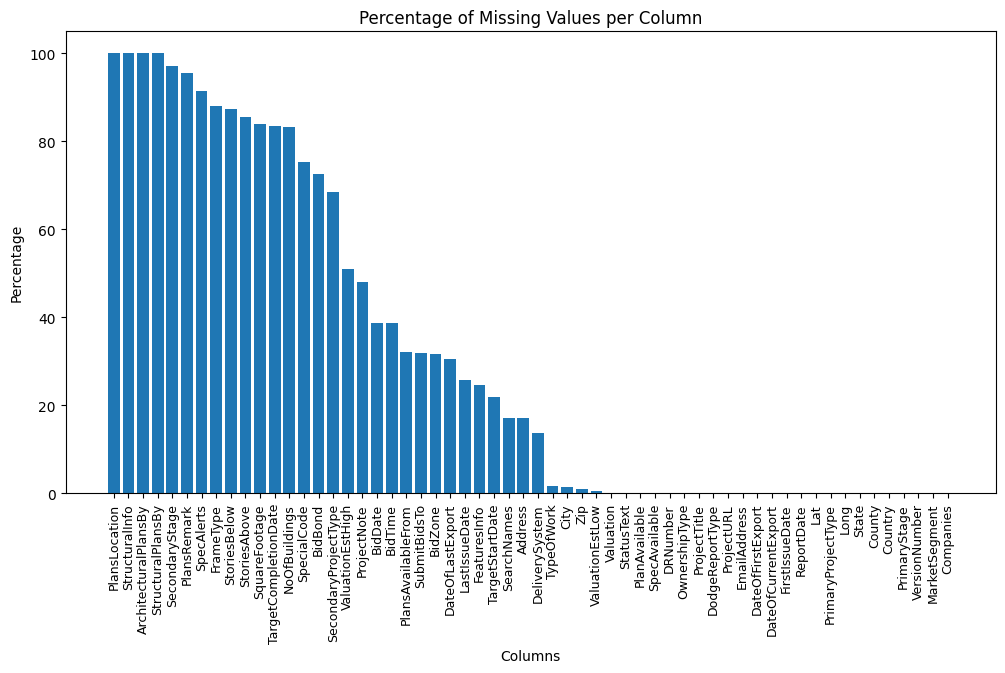

In [321]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12, 6))
plt.bar(null_counts_sorted.index, null_counts_sorted.values) 
plt.xlabel('Columns')
plt.xticks(rotation=90, size=9)
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [322]:
# Fetch relevant Dodge columns for ranking 
relevant_dodge_columns = [
    "Lat", "Long",
    "StatusText", "FeaturesInfo",
    "PlanAvailable",
    "SpecAvailable",
    "OwnershipType",
    "TypeOfWork",
    "MarketSegment",
    "PrimaryProjectType",
    "DRNumber",
    "PrimaryStage",
    "ProjectTitle",
    "Valuation",
    "Companies",
    "BidDate",
    "BidTime"
]

df_relevant = df[relevant_dodge_columns]

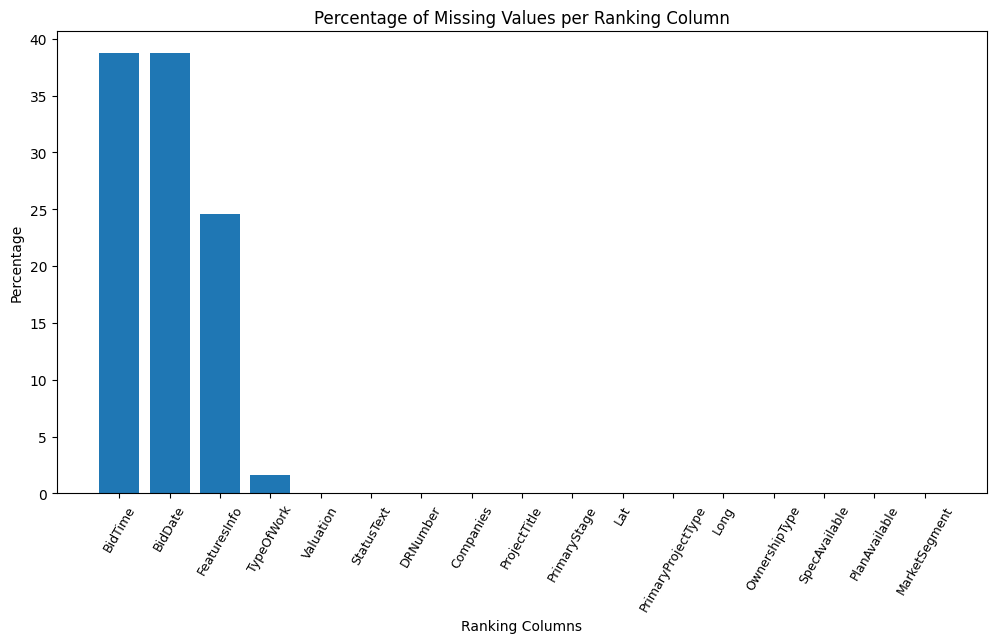

In [323]:
# Check missing values in ranking columns 
null_counts_relevant = df_relevant.isnull().sum()/ len(df) * 100
null_counts_sorted_relevant = null_counts_relevant.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(null_counts_sorted_relevant.index, null_counts_sorted_relevant.values) 
plt.xlabel('Ranking Columns')
plt.xticks(rotation=60, size=9)
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values per Ranking Column')
plt.show()

Notes: 
- Columns for deduplication (Title, Companies, Lat, Long) are all available 
- FeaturesInfo available in 75% of data -- used to fetch relevant materials 


In [324]:
df.iloc[0]['Companies']

{'Company': [{'FactorType': 'Engineer',
   'FactorKey': 'HAZNY0635',
   'CKMSID': 'CKS000000162145',
   'BidRank': None,
   'BidAmount': None,
   'CompanyName': 'Hazen & Sawyer',
   'CompanyLat': None,
   'CompanyLong': None,
   'CompanyAddress': '498 Fashion Ave Fl 11',
   'CompanyCity': 'New York',
   'CompanyState': 'NY',
   'CompanyCounty': 'NEW YORK',
   'CompanyZip': '10018-6761',
   'CompanyCountry': 'USA',
   'CompanyTelephone': '212-539-7000',
   'CompanyWebsite': 'http://www.hazenandsawyer.com',
   'ContactID': None,
   'ContactTitle': None,
   'CompanyFax': '212-614-9049',
   'ContactName': None,
   'ContactEmail': 'nnelson@hazenandsawyer.com',
   'ContactPhone': '212-539-7000'},
  {'FactorType': 'Owner',
   'FactorKey': 'WESNY0007',
   'CKMSID': 'CKS000000304286',
   'BidRank': None,
   'BidAmount': None,
   'CompanyName': 'Westchester Joint Water Works',
   'CompanyLat': None,
   'CompanyLong': None,
   'CompanyAddress': '1625 MAMARONECK AVE\xa0PO BOX 398',
   'CompanyCity

In [326]:
# Fetch owner information from 'Companies' column
def owner_in_dict(companies_dict): 
    companies = companies_dict.get('Company', [])
    for company in companies:
        if isinstance(company, dict) and company.get('FactorType').lower().strip() == 'owner':
            return True
    return False

# Check if 'Companies' column contains owner information 
df['contains_company_owner'] = df['Companies'].apply(lambda x: owner_in_dict(x) if isinstance(x, dict) else False)

# Calculate the percentage of projects with owner information available
contains_owner_percent = len(df[df['contains_company_owner'] == True])/len(df) * 100 
print("Percantage of projects with owner available:", contains_owner_percent)

Percantage of projects with owner available: 72.15482706088135


In [327]:
# Look at company owners
unique_companies = set() 

for idx, row in df.iterrows():
    # Fetch company list 
    if isinstance(row['Companies'], dict):
        companies = row['Companies'].get('Company', [])
        # Fetch owners
        for company in companies:
            if isinstance(company, dict) and company.get('FactorType').lower().strip() == 'owner':
                unique_companies.add(company['CompanyName'])

In [328]:
print(unique_companies)

{'Active Acquisitions', 'County of Sacramento', 'Town of Medfield', 'Walter Wayne Development, LLC', 'State University of New York', 'Town of Tatum', 'Union Gospel Mission', 'Basis Industrial Acquisitions, LLC', 'Port of Morrow', 'Town of Leicester Board of Selectmen', 'City of Saint Charles', 'Oklahoma State Department of Transportation', 'University of Missouri Planning/Design/Const', 'City of Rialto', 'City of Leonard', 'Furniture Row Usa Llc', '5448 Spalding Drive Llc', 'Gardiner-Park County Water District', 'SUCF State University Construction Fund', 'City of Shenandoah', 'Sacramento City Unified School District', 'Select Medical Corp', 'Town of Chesterfield', 'Conroe MMD #1', 'Pablo Rapaporte', 'Town of Minisink', 'Mississippi Band of Choctaw Indians', 'Village of Seven Mile', 'Northeastern Hospitality Group LLC', 'Martin County Board of Commissioners', 'Clay Electric Cooperative, Inc.,', 'Albuquerque Public Schools Procurement Division', 'Elmira Heights Central School District', 

In [329]:
markets = set() 

# Check unique markets 
for market_segment in df['MarketSegment'].unique():
    if isinstance(market_segment, str):
        markets.update(re.split(r',\s*', market_segment))  # Split by comma and strip whitespace
        
print("Unique Markets: ", markets)

Unique Markets:  {'Industrial', 'Medical', 'Multi-Residential', 'Engineering', 'Funeral', 'Commercial', 'Houses', 'Public', 'Worship', 'Animal/Plant', 'Housing', 'Utilities', 'School', 'Transport', 'Leisure', 'Unclassified'}


## Check distribution of stages
- Stages used to filter out prospective projects in pipeline

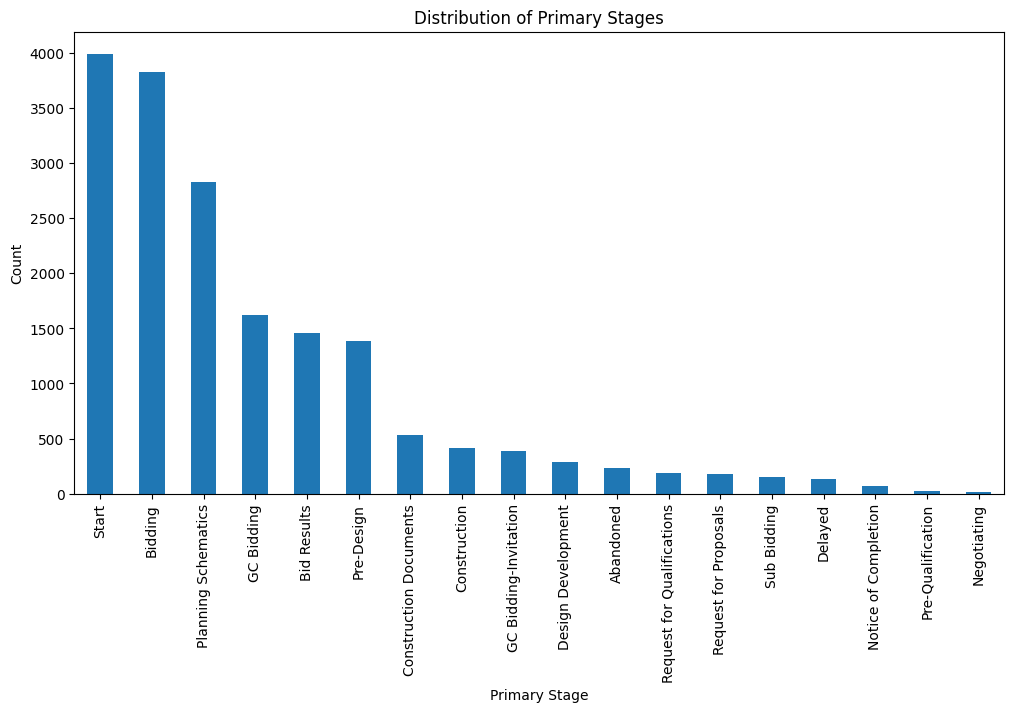

In [330]:
primary_stage_counts = df['PrimaryStage'].value_counts()
plt.figure(figsize=(12, 6))
primary_stage_counts.plot(kind='bar')
plt.xlabel('Primary Stage')
plt.ylabel('Count')
plt.title('Distribution of Primary Stages')
plt.show()

In [331]:
# Fetch current stages from ConstructConnect feed
cc_stage_query = f"select stage from {PROJECT_ID}.{DATASET}.{CC_TABLE} where stage is not null group by stage"
query_job = client_bq.query(cc_stage_query)
stages_df = query_job.to_dataframe()
cc_stages = stages_df['stage'].unique()

In [332]:
print(cc_stages)

['Construction Underway' 'Post Bid' 'Biddate Set' 'Low Bids Announced'
 'Construction Documents' 'Cancelled' 'Design Development'
 'Disqualified Lead' 'Bids Closed' 'SUBBIDS: ASAP'
 'General Contractor Award' 'Schematic Design' 'Pre-Design'
 'Duplicate Project']


In [333]:
for stage in sorted(df['PrimaryStage'].unique()): 
    print(stage)

Abandoned
Bid Results
Bidding
Construction
Construction Documents
Delayed
Design Development
GC Bidding
GC Bidding-Invitation
Negotiating
Notice of Completion
Planning Schematics
Pre-Design
Pre-Qualification
Request for Proposals
Request for Qualifications
Start
Sub Bidding


## Check distribution of project valuation

In [334]:
def assign_valuation_bucket(value: float) -> str: 
    try:
        if value >= 100000000:
            return ">100M"
        elif 50000000 <= value < 100000000:
            return "50M-100M"
        elif 25000000 <= value < 50000000:
            return "25M-50M"
        elif 10000000 <= value < 25000000:
            return "10M-25M"
        elif 5000000 <= value < 10000000:
            return "5M-10M"
        elif 2000000 <= value < 5000000:
            return "2M-5M"
        elif 1000000 <= value < 2000000:
            return "1M-2M"
        else:
            return "Under 1M"
    except (ValueError, AttributeError):
        return "Invalid Value"

In [335]:
# Calculate valuation buckets for Dodge data
df['Valuation'] = df['Valuation'].astype(float)
df['Valuation_Millions'] = df['Valuation'].apply(assign_valuation_bucket)

buckets = ["Under 1M", "1M-2M", "2M-5M", "5M-10M", "10M-25M", "25M-50M", "50M-100M", ">100M"]
df['Valuation_Millions'] = pd.Categorical(df['Valuation_Millions'], categories=buckets, ordered=True)

In [336]:
# Fetch CC valuation values
valuation_query = f"""select Valuation_Value from {PROJECT_ID}.{DATASET}.{CC_TABLE} 
                    limit {len(df)}""" 
query_job = client_bq.query(valuation_query)
cc_df_valuation = query_job.to_dataframe()

In [337]:
# Calculate valuation buckets for CC data
cc_df_valuation['Valuation_Value'] = cc_df_valuation['Valuation_Value'].astype(float)
cc_df_valuation['Valuation_Millions'] = cc_df_valuation['Valuation_Value'].apply(assign_valuation_bucket)
cc_df_valuation['Valuation_Millions'] = pd.Categorical(cc_df_valuation['Valuation_Millions'], categories=buckets, ordered=True)

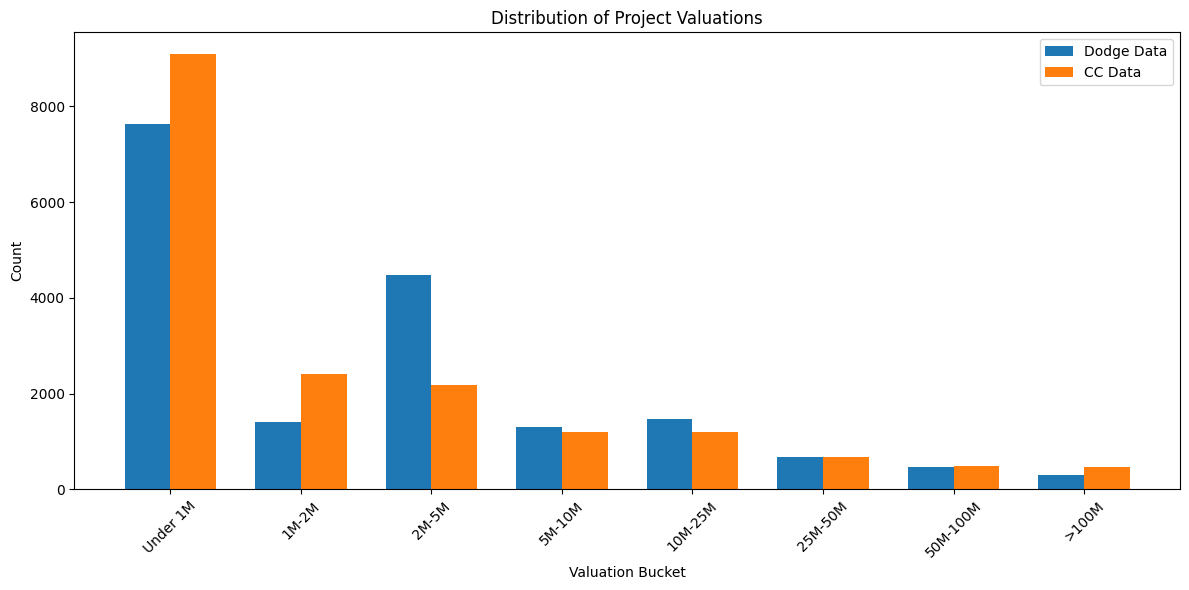

In [338]:
# Get value counts for both DataFrames
dodge_valuation_counts = df['Valuation_Millions'].value_counts().sort_index()
cc_valuation_counts = cc_df_valuation['Valuation_Millions'].value_counts().sort_index()

# Create a figure and an axes
plt.figure(figsize=(12, 6))

# Plot the distributions
width = 0.35  # Width of the bars

x = range(len(buckets)) 
plt.bar(x, dodge_valuation_counts, width, label='Dodge Data')
plt.bar([i + width for i in x], cc_valuation_counts, width, label='CC Data')

# Customize the plot
plt.xlabel('Valuation Bucket')
plt.ylabel('Count')
plt.title('Distribution of Project Valuations')
plt.xticks([i + width / 2 for i in x], buckets, rotation=45)  # Set x-axis labels and rotate
plt.legend()
plt.tight_layout()
plt.show()